# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[ResNet-18] Epoch   1/100 | LR: 2.93e-04 | train loss 0.8684 acc 0.672 | val loss 0.6663 acc 0.689 *


[ResNet-18] Epoch   2/100 | LR: 2.93e-04 | train loss 0.6193 acc 0.767 | val loss 0.5871 acc 0.707 *


[ResNet-18] Epoch   3/100 | LR: 2.93e-04 | train loss 0.5275 acc 0.812 | val loss 0.7159 acc 0.727


[ResNet-18] Epoch   4/100 | LR: 2.93e-04 | train loss 0.4289 acc 0.848 | val loss 0.5679 acc 0.801 *


...

[ResNet-18] Epoch  15/100 | LR: 2.93e-04 | train loss 0.1044 acc 0.965 | val loss 0.6489 acc 0.827


[ResNet-18] Epoch  16/100 | LR: 2.93e-04 | train loss 0.0306 acc 0.993 | val loss 0.6912 acc 0.845


[ResNet-18] Epoch  17/100 | LR: 2.93e-04 | train loss 0.0756 acc 0.974 | val loss 0.5864 acc 0.821


[ResNet-18] Epoch  18/100 | LR: 2.93e-04 | train loss 0.0751 acc 0.982 | val loss 0.8180 acc 0.762


[ResNet-18] Epoch  19/100 | LR: 2.93e-04 | train loss 0.0712 acc 0.980 | val loss 0.8479 acc 0.806

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-18] Restored best checkpoint (val loss = 0.4844)


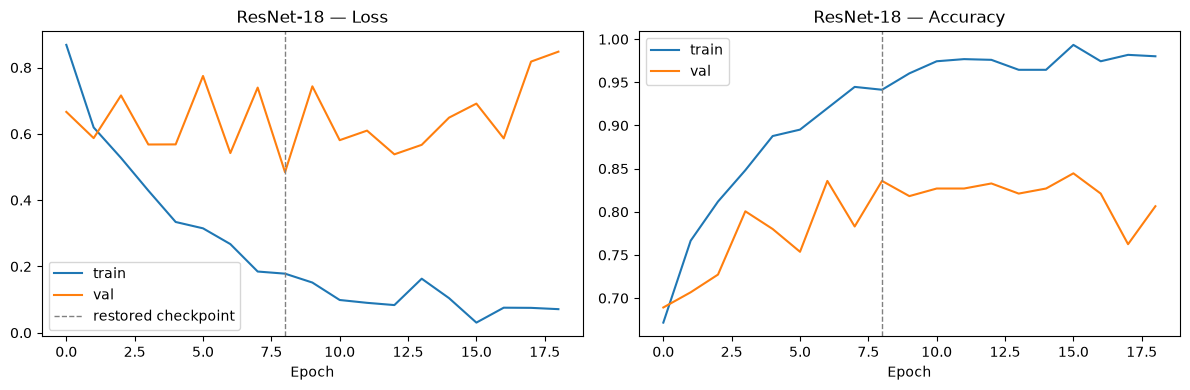

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.795


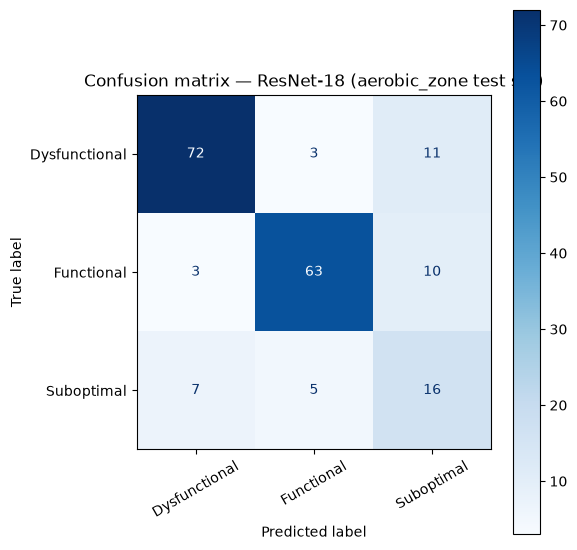

               precision    recall  f1-score   support

Dysfunctional      0.878     0.837     0.857        86
   Functional      0.887     0.829     0.857        76
   Suboptimal      0.432     0.571     0.492        28

     accuracy                          0.795       190
    macro avg      0.733     0.746     0.736       190
 weighted avg      0.816     0.795     0.803       190



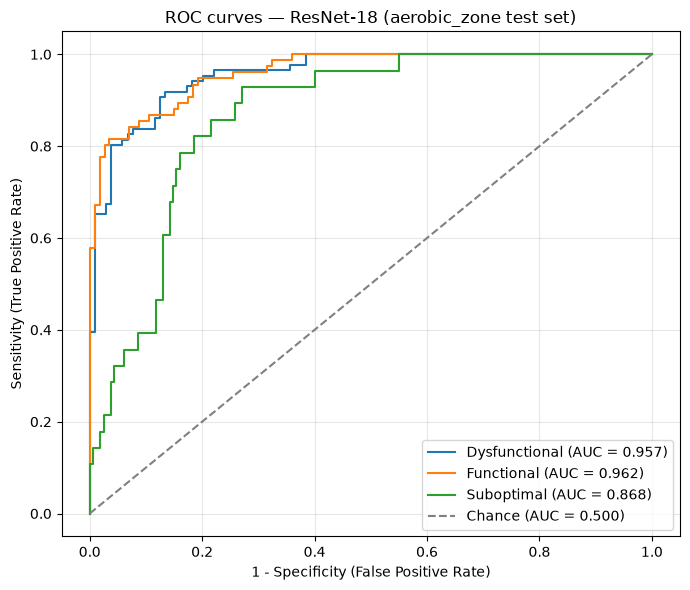

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.957
  Functional     : 0.962
  Suboptimal     : 0.868

Mean AUC (over 3/3 classes with test examples): 0.929


(np.float64(0.7947368421052632),
 {'Dysfunctional': 0.9574016100178891,
  'Functional': 0.9615650969529086,
  'Suboptimal': 0.8679453262786596})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_resnet18_stratified.pkl


Saved model weights to ../models/aerobic_zone_resnet18_cnn.pt
